In [ ]:
# 초기 1회 실행
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Project

In [ ]:
## 필요 패키지 설치 및 import
import importlib.util
import subprocess
import sys
def install_and_import(packages):
    for pkg in packages:
        package = pkg
        try:
            importlib.util.find_spec(package)
            print(f"{package} is already installed.")
        except ImportError:
            # 모듈이 설치되어 있지 않은 경우 설치시도
            print(f"{package} is not installed. Installing...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            subprocess.check_call(["conda", "install", package, "-y"])

            # 설치 후 다시 임포트를 시도
            importlib.import_module(package)
            print(f"{package} has been successfully installed.")

        # finally:
        #     globals()[package] = importlib.import_module(package)
        except Exception as e:
            # 설치 중 예외가 발생한 경우, 에러 메시지를 출력
            print(f"An error occurred while installing {package}: {str(e)}")

# 예시 사용법
# install_and_import(['mlxtend'])


In [ ]:
ppath = '/content/drive/MyDrive/AI LLM/김동환 강사님_강의자료_메타코드M/lesson4'

In [ ]:
## 필요 모듈 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, roc_curve, auc


# 데이터 읽기

In [ ]:
rd = pd.read_csv(ppath + '/1. data/loan_sampled.csv')
df = rd
df.shape

(5756, 16)

In [ ]:
df.head().T

,0,1,2,3,4
Unnamed: 0,27801,14225,6043,21221,22328
annual_inc,63000.0,140000.0,60000.0,79658.0,59000.0
bc_util,30.7,87.9,95.9,78.3,74.5
dti,24.84,6.11,15.36,7.01,12.12
num_accts_ever_120_pd,0,0,0,0,1
pub_rec_bankruptcies,1,0,0,0,0
tax_liens,0,0,0,0,0
tot_hi_cred_lim,153285,42388,98248,234936,80058
total_bc_limit,14700,28800,19900,13400,6400
avg_cur_bal,7253,5564,4042,18704,13720


1. annual_inc: 연간 소득
2. bc_util: 대출 신청자의 사용 가능한 신용 카드 한도 중 사용된 비율
3. dti: (Debt-to-Income Ratio). 총 부채가 연간 소득에서 차지하는 비율
4. num_accts_ever_120_pd: 120일 이상 연체된 계좌 수  
5. pub_rec_bankruptcies:  대출 신청자의 파산 기록 횟수
6. tax_liens: 세금 체납으로 인해 설정된 유치권의 수
7. tot_hi_cred_lim: 신용카드 및 대출 계좌의 총 신용 한도
8. total_bc_limit: 신용 카드 한도 총액
9. avg_cur_bal: 평균 현재 잔액
10. pct_tl_nvr_dlq: 연체된 적 없는 계좌 비율
11. total_acc: 총 계좌 수
12. int_rate: 대출 이자율
13. home_ownership: 주택 소유 형태, 'MORTGAGE' (담보 대출), 'RENT' (임대), 'OWN' (소유)
14. term: 대출 기간
15. TARGET: 대출 상환(승인) 여부를 나타내는 변수. 0은 정상 상환, 1은 연체 또는 부도 의미



### 범주형 변수 처리

In [ ]:
## 범주형 변수 변환 ('home_ownership', 'term')  원핫 인코딩 적용
df = pd.get_dummies(df,
                                              columns = ['home_ownership',
                                                                   'term'],
                                              drop_first = True)

df['home_ownership_OWN'] = df['home_ownership_OWN'].astype(int)
df['home_ownership_RENT'] = df['home_ownership_RENT'].astype(int)
df['term_ 60 months'] = df['term_ 60 months'].astype(int)

## 결측치 제거
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5756 entries, 0 to 5755
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             5756 non-null   int64  
 1   annual_inc             5756 non-null   float64
 2   bc_util                5756 non-null   float64
 3   dti                    5756 non-null   float64
 4   num_accts_ever_120_pd  5756 non-null   int64  
 5   pub_rec_bankruptcies   5756 non-null   int64  
 6   tax_liens              5756 non-null   int64  
 7   tot_hi_cred_lim        5756 non-null   int64  
 8   total_bc_limit         5756 non-null   int64  
 9   avg_cur_bal            5756 non-null   int64  
 10  pct_tl_nvr_dlq         5756 non-null   float64
 11  total_acc              5756 non-null   int64  
 12  int_rate               5756 non-null   float64
 13  TARGET                 5756 non-null   int64  
 14  home_ownership_OWN     5756 non-null   int64  
 15  home

### Train/Test 분할

In [ ]:
## 독립변수들 Feature와  종속변수 Target 분리
X = df.drop('TARGET', axis=1)
y = df['TARGET']



## Train/New data set으로 분할


In [ ]:
## Train/Test 데이터 분할 (test_size = 0.2)
X_train, X_test, y_train, y_test = train_test_split(X,
                                                                                                   y,
                                                                                                   test_size = 0.2,
                                                                                                   random_state = 123)

## 표준화(미리 해놓기)

In [ ]:
from sklearn.preprocessing import StandardScaler

## 연속형 변수만 선택하여 표준화
continuous_features = X.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])

X_test_scaled = X_test.copy()
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])


## KNN



In [ ]:
results = {} # 결과 저장용

### 모델 학습

In [ ]:
## 모델 학습
knn = KNeighborsClassifier(n_neighbors = 30) # 원래 기본값은 5
knn.fit(X_train_scaled, y_train) # 표준화 O

KNeighborsClassifier(n_neighbors=30)

In [ ]:
# from sklearn.model_selection import GridSearchCV

# ## 만약 사용자 파라미터 최적화를 할 경우
# param_grid = {'n_neighbors': [5, 10, 30],
#                              'weights': ['uniform', 'distance']}
# grid_search = GridSearchCV(KNeighborsClassifier(),
#                                                           param_grid = param_grid,
#                                                           cv = 5,
#                                                           refit = True,
#                                                           scoring = 'accuracy',
#                                                           verbose = 3
#                                                         )

# grid_search.fit(X_train_scaled, y_train)
# best_model_knn = grid_search.best_estimator_
# print(grid_search.best_params_)

# knn = best_model_knn

### 테스트 데이터에 대해서 예측

In [ ]:
## 테스트 데이터에 대해서 예측
y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

### 정확도, ROC 커브, AUC  계산



In [ ]:
## 정확도 계산
accuracy_knn = accuracy_score(y_test, y_pred_knn)
accuracy_knn


0.7534722222222222

KNN AUC: 0.6639801150977366


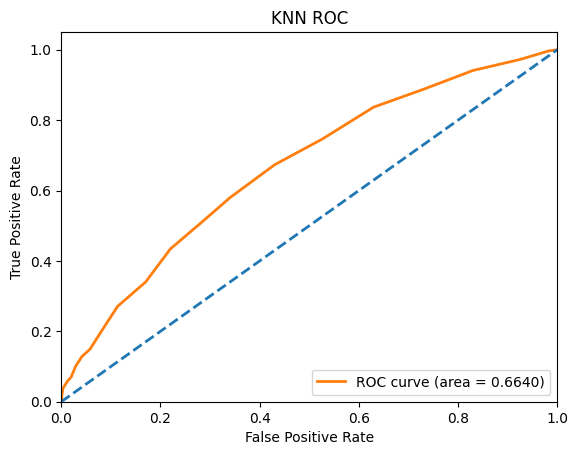

In [ ]:
## ROC 커브 그리기
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
roc_auc_knn = auc(fpr, tpr)
print("KNN AUC:",  roc_auc_knn)

# ROC 커브 플롯
plt.figure()
plt.plot(fpr, tpr, color='C1', lw=2, label=f'ROC curve (area = {roc_auc_knn:.4f})')
plt.plot([0, 1], [0, 1], color='C0', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("KNN ROC")
plt.legend(loc="lower right")
plt.show()



### 결과 저장

In [ ]:
results["KNN"] = {'accuracy': accuracy_knn, 'auc': roc_auc_knn}

## SVM



### 모델 학습

In [ ]:
## 모델 학습
svm = SVC(probability = True)
svm.fit(X_train_scaled, y_train) # 표준화 O

SVC(probability=True)

In [ ]:
# from sklearn.model_selection import GridSearchCV

# ## 만약 사용자 파라미터 최적화를 할 경우
# param_grid = {'C': [0.1,  1,  10],
#                                'gamma': [1,  0.1,  0.01],
#                                 'kernel': ['rbf']}
# grid_search = GridSearchCV( SVC(probability = True),
#                                                           param_grid = param_grid,
#                                                           cv = 5,
#                                                           refit = True,
#                                                           scoring = 'accuracy',
#                                                           verbose = 3
#                                                          )

# grid_search.fit(X_train_scaled, y_train)
# best_model_svm = grid_search.best_estimator_
# print(grid_search.best_params_)

# svm = best_model_svm

### 테스트 데이터에 대한 예측

In [ ]:
## 테스트 데이터에 대해서 예측
y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

### 정확도, ROC 커브, AUC 계산

In [ ]:
## 정확도 계산
accuracy_svm = accuracy_score(y_test, y_pred_svm)
accuracy_svm


0.7526041666666666

SVM AUC: 0.6120555234053497


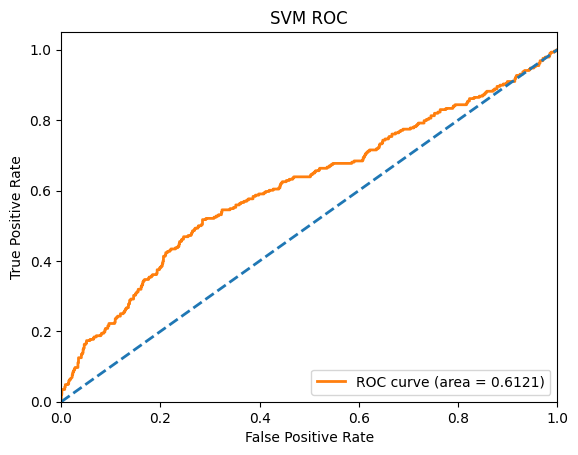

In [ ]:
## ROC 커브 그리기
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr, tpr)
print("SVM AUC:",  roc_auc_svm)

# ROC 커브 플롯
plt.figure()
plt.plot(fpr, tpr, color='C1', lw=2, label=f'ROC curve (area = {roc_auc_svm:.4f})')
plt.plot([0, 1], [0, 1], color='C0', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("SVM ROC")
plt.legend(loc="lower right")
plt.show()



### 결과 저장

In [ ]:
results["SVM"] = {'accuracy': accuracy_svm, 'auc': roc_auc_svm}

## Decision Tree

### 모델 학습


In [ ]:
## 모델 학습
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train) ## 표준화 X

DecisionTreeClassifier()

In [ ]:
# from sklearn.model_selection import GridSearchCV

# ## 만약 사용자 파라미터 최적화를 할 경우
# param_grid = {'max_depth':  [None, 10, 20, 30],
#                               'min_samples_split':  [2, 10, 20]}
# grid_search = GridSearchCV(DecisionTreeClassifier(),
#                                                            param_grid = param_grid,
#                                                            cv = 5,
#                                                            refit = True,
#                                                            scoring = 'accuracy',
#                                                            verbose = 3
#                                                           )

# grid_search.fit(X_train_scaled, y_train)
# best_model_dt = grid_search.best_estimator_
# print(grid_search.best_params_)

# dt = best_model_dt

### 테스트 데이터에 대한 예측

In [ ]:
## 테스트 데이터에 대해서 예측
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

### 정확도, ROC 커브, AUC 계산

In [ ]:
## 정확도 계산
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_dt


0.6614583333333334

Decision Tree AUC: 0.5555555555555556


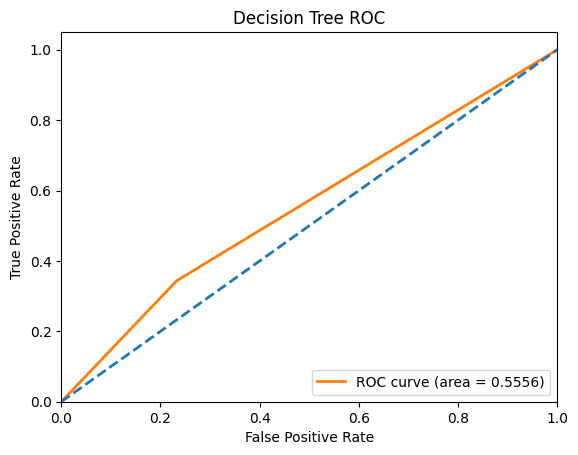

In [ ]:
## ROC 커브 그리기
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr, tpr)
print("Decision Tree AUC:",  roc_auc_dt)

# ROC 커브 플롯
plt.figure()
plt.plot(fpr, tpr, color='C1', lw=2, label=f'ROC curve (area = {roc_auc_dt:.4f})')
plt.plot([0, 1], [0, 1], color='C0', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("Decision Tree ROC")
plt.legend(loc="lower right")
plt.show()



### 결과 저장

In [ ]:
results["DT"] = {'accuracy': accuracy_dt, 'auc': roc_auc_dt}

## Naive Bayes


### 모델학습


In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train) # 표준화 X

GaussianNB()

In [ ]:
# NB는 하이퍼파라미터가 기본적으로는 없음..

### 테스트 데이터에 대한 예측

In [ ]:
## 테스트 데이터에 대해서 예측
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1]

### 정확도, ROC 커브, AUC 계산

In [ ]:
## 정확도 계산
accuracy_nb = accuracy_score(y_test, y_pred_nb)
accuracy_nb


0.7100694444444444

Naive Bayes AUC: 0.6664215213477366


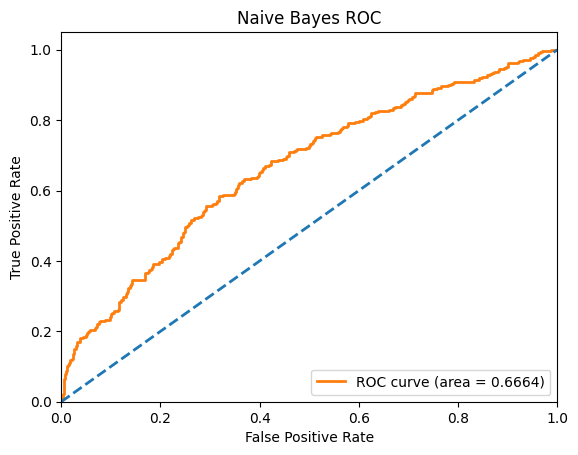

In [ ]:
## ROC 커브 그리기
fpr, tpr, _ = roc_curve(y_test, y_prob_nb)
roc_auc_nb = auc(fpr, tpr)
print("Naive Bayes AUC:",  roc_auc_nb)

# ROC 커브 플롯
plt.figure()
plt.plot(fpr, tpr, color='C1', lw=2, label=f'ROC curve (area = {roc_auc_nb:.4f})')
plt.plot([0, 1], [0, 1], color='C0', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("Naive Bayes ROC")
plt.legend(loc="lower right")
plt.show()



### 결과 저장

In [ ]:
results["NB"] = {'accuracy': accuracy_nb, 'auc': roc_auc_nb}

## 결과비교

In [ ]:
## training result
y_pred_knn_tr = knn.predict(X_train_scaled)
accuracy_knn_tr = accuracy_score(y_train, y_pred_knn_tr)

y_pred_svm_tr = svm.predict(X_train_scaled)
accuracy_svm_tr = accuracy_score(y_train, y_pred_svm_tr)

y_pred_dt_tr = dt.predict(X_train)
accuracy_dt_tr = accuracy_score(y_train, y_pred_dt_tr)

y_pred_nb_tr = nb.predict(X_train)
accuracy_nb_tr = accuracy_score(y_train, y_pred_nb_tr)


In [ ]:
results_train_df = pd.DataFrame({
    'Method': ['KNN', 'SVM', 'DT', 'NB'],
    'Train Accuracy': [accuracy_knn_tr, accuracy_svm_tr, accuracy_dt_tr, accuracy_nb_tr],
}).T
results_train_df.columns = results_train_df.iloc[0]
results_train_df = results_train_df.drop(results_train_df.index[0])
results_train_df


Method,KNN,SVM,DT,NB
Train Accuracy,0.773458,0.779757,1.0,0.7298


In [ ]:
## 테스트 데이터 결과
results_test_df = pd.DataFrame(results)
results_test_df

,KNN,SVM,DT,NB
accuracy,0.753472,0.752604,0.661458,0.710069
auc,0.663980,0.612056,0.555556,0.666422


In [ ]:
## 해석 예시
# 학습데이터에서 가장 성능이 좋았던 DT는 Test에서는 가장 안좋은 성능이 나옴
# NB는 학습데이터에서 가장 성능이 나빴으나 테스트데이터에서의 성능차가 가장 적었음



In [ ]:
# EOS